In [ ]:
# # conda create -n "Gen" python=3.9.12 ipython    Note: Gen is the name of the enviornment.
# # conda activate Gen
# !pip install numpy
# !pip install pandas
# !pip install matplotlib
# !pip install scikit-learn
# !pip install tensorflow
# !pip install pmdarima
# !pip install prophet

In [ ]:
# !pip install yfinance 

In [1]:
from numpy import mean, absolute
from itertools import chain
import pandas as pd
from datetime import date
import datetime
import matplotlib.pyplot as plt
import numpy as np
from random import random
from time import sleep
import warnings
warnings.filterwarnings('ignore')
warnings.filterwarnings("ignore", category=FutureWarning)

import yfinance as yf

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

import tensorflow as tf
from tensorflow.keras.layers import Dense, LSTM, GRU
from tensorflow.keras.models import Sequential
from keras.layers import Dropout
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import Flatten
from keras.layers import LSTM
from keras.layers import RepeatVector
from keras.layers import TimeDistributed
from keras.layers.convolutional import Conv1D
from keras.layers.convolutional import MaxPooling1D
from tensorflow.keras.layers import SimpleRNN

# from pmdarima.arima import auto_arima
# from pmdarima.arima import ADFTest

# from prophet import Prophet

2023-01-27 16:39:52.351647: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2023-01-27 16:39:52.420465: I tensorflow/core/util/port.cc:104] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2023-01-27 16:39:52.710785: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer.so.7'; dlerror: libnvinfer.so.7: cannot open shared object file: No such file or directory
2023-01-27 16:39:52.710830: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not l

In [2]:
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
  try:
    # Currently, memory growth needs to be the same across GPUs
    for gpu in gpus:
      tf.config.experimental.set_memory_growth(gpu, True)
    logical_gpus = tf.config.experimental.list_logical_devices('GPU')
    print(len(gpus), "Physical GPUs,", len(logical_gpus), "Logical GPUs")
  except RuntimeError as e:
    # Memory growth must be set before GPUs have been initialized
    print(e)

2023-01-27 16:39:53.426478: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2023-01-27 16:39:53.454567: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudnn.so.8'; dlerror: libcudnn.so.8: cannot open shared object file: No such file or directory
2023-01-27 16:39:53.454583: W tensorflow/core/common_runtime/gpu/gpu_device.cc:1934] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


### Load Dataset

In [3]:
stockName = '^GDAXI'
origDF = yf.download(tickers=[stockName], period='20y')
# origDF = yf.download(tickers=[stockName], period='60d', interval="5m")
y = origDF['Close'].fillna(method='ffill').values.reshape(- 1, 1)
origDF.reset_index(inplace=True)
# print(df.shape)
origDF = origDF.rename({'Datetime': 'Date'}, axis=1)
# origDF['Date'] = origDF['Date'].dt.tz_localize(None)
print(origDF.shape)
origDF.head()

[*********************100%***********************]  1 of 1 completed
(5081, 7)


,Date,Open,High,Low,Close,Adj Close,Volume
0,2003-01-27 00:00:00+01:00,2716.419922,2728.280029,2615.669922,2643.800049,2643.800049,127433000
1,2003-01-28 00:00:00+01:00,2649.959961,2705.219971,2616.040039,2671.360107,2671.360107,110596000
2,2003-01-29 00:00:00+01:00,2667.689941,2743.100098,2563.919922,2706.570068,2706.570068,136367100
3,2003-01-30 00:00:00+01:00,2711.840088,2742.919922,2665.520020,2693.780029,2693.780029,115937300
4,2003-01-31 00:00:00+01:00,2687.719971,2753.260010,2622.409912,2747.830078,2747.830078,106047400


### Data Preprocessing

#### Stock  Graph

In [4]:
import plotly.express as px
import plotly.io as pio
pio.renderers.default = 'iframe' # or 'notebook' or 'colab' or 'jupyterlab'

fig =px.line(origDF,x='Date', y='Close', hover_data=['Date', 'Open', 'High', 'Low', 'Close'])
fig.show()

### Deep Learning Models

In [5]:
from keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

earlyStopping = EarlyStopping(monitor='val_loss', patience=5, verbose=0, mode='min')
mcp_save = ModelCheckpoint('.mdl_wts.hdf5', save_best_only=True, monitor='val_loss', mode='min')

#### RNN Model

In [ ]:
# def RNNModel(trainX, trainY, X):  
#     tf.random.set_seed(0)
    
#     model = Sequential()
    
#     model.add(SimpleRNN(units=128, input_shape=(X.shape[1], X.shape[2]), activation=actFunc))
    
#     # model.add(LSTM(units = 50, return_sequences = True))
    
#     model.add(Dense(64, activation=actFunc)) 
    
#     model.add(Dense(32, activation=actFunc)) 
    
#     model.add(Dense(8, activation=actFunc)) 
    
#     model.add(Dense(1))
    
#     model.compile(loss='mean_squared_error', optimizer='rmsprop')
    
#     model.summary()
        
#     ''' Train Model '''
#     model.fit(trainX, trainY, epochs=50, batch_size=8, validation_split=0.1, verbose=2, callbacks=[earlyStopping, mcp_save])
    
#     return model

#### GRU Model

In [51]:
def GRUModel(trainX, trainY, X, actFunc):  

    tf.random.set_seed(0)
    
    model = Sequential()
    
    model.add(GRU(units = 128, return_sequences = True, input_shape = [X.shape[1], X.shape[2]], activation=actFunc))
    
    model.add(Dropout(0.2)) 

    model.add(GRU(units = 64, activation=actFunc)) 
    
    model.add(Dropout(0.2))
    
    model.add(Dense(units = 1, activation=actFunc))
    
    model.compile(optimizer='adam',loss='mse') # 'mean_squared_error' # 'rmsprop'
    
    model.summary()
        
    ''' Train Model '''
    model.fit(trainX, trainY, epochs=50, batch_size=32, validation_split=0.1, verbose=2, callbacks=[earlyStopping, mcp_save])
    
    return model

#### MAPE Calc. DL

In [52]:
def testSetPred_DLLModels(model, name, test_df, testX, testY, scaler):
    
    ''' TEST SET PREDICTION '''
    testPred = model.predict(testX)
    testPred = np.array(testPred).reshape(-1, 1)
    testPred = scaler.inverse_transform(testPred)
    testPred = list(chain.from_iterable(testPred.tolist()))

    temptestY = testY
    temptestY = np.array(temptestY).reshape(-1, 1)
    temptestY = scaler.inverse_transform(temptestY)
    temptestY = list(chain.from_iterable(temptestY.tolist()))


    MAPEScore = mean_absolute_percentage_error(temptestY, testPred)
    RMSEScore = mean_squared_error(temptestY, testPred, squared=False)
    print("\n")
    print(f"MAPE: {str(MAPEScore)}")
    print(f"RMSE: {str(RMSEScore)}")

    accDF = test_df.copy()
    pred = testPred
    # pred.extend([14541.379])
    accDF = accDF.rename({'Date': 'DATE'}, axis=1)  # new method
    accDF[name] = pred
    accDF.to_csv(f'csvFiles_batch64/{name}_Predictions.csv', index=False)
    print(f"Testing result for {actFunc} Function")
    accDF.plot(x='DATE')
    # print(f"MAPE Calculation Done, MAPE: {str(MAPEScore)}")
    return MAPEScore, accDF, RMSEScore

#### Out of Sample Forecast DL

In [37]:
def OutOfSampleFrct_DLLModels(model, name, testX, scaler, futureFrcstNmbr):
    ''' OUT OF SAMPLE FORECASTING'''
    lastSeq = testX[-1:] # Get the Last Sequence from the Dataset
    forecast = futureFrcstNmbr # Change for required number of Forecasts
    futurePred = [] # Store Forecasts in List

    for i in range(forecast):
        if i == 0: # If first iteration use Last Observed Sequence
            # print([lastSeq.shape])
            currPred = model.predict([lastSeq]) # Reshape Last Obeserved Sequence into 3d and Predict
            transPred = scaler.inverse_transform(currPred) # Inverse Transform to get Real Values
            transPred = list(transPred.flatten()) # Flat the predicted array to 2D
            futurePred.append(transPred) # Append in Forecasts List
        elif i > 0:
            print(i)
            currPred = currPred.reshape([1,1,1]) # Reshape latest Predicted Value into (1,1,1) to get the format the Model Requires
            # print([currPred])
            currPred = model.predict([currPred])
            transPred = scaler.inverse_transform(currPred) # Inverse Trasnform to get Real Values
            transPred = list(transPred.flatten()) # Flat the predicted array to 2D
            print(transPred)
            futurePred.append(transPred) # Append in Forecasts List
    
    print("Out of Sample Forecasting Done!")
    
#     ossArrOrig = list(chain.from_iterable(futurePred))
#     ossArrDF = pd.DataFrame(ossArrOrig,columns =[f'{name}_OutOfSampleForecast'])
    
#     currDate = df.tail(1)
#     currDate = currDate.Date.values[0]
#     currDate = datetime.datetime.strptime(currDate, '%d/%m/%Y')
#     nextDate = currDate + datetime.timedelta(days=1)

#     # ossArrDF = pd.read_csv('futureForecast/LSTM_OutOfSampleForecast.csv')
#     ossArrDF['ds'] = pd.date_range(start=nextDate, periods=len(ossArrDF), freq='D')
#     ossArrDF.insert(0, 'ds', ossArrDF.pop('ds'))

#     ossArrDF.to_csv(f'futureForecast/{name}_OutOfSampleForecast.csv',index=False)
#     ossArrDF.plot(x="ds", y=f"{name}_OutOfSampleForecast")
    
    return futurePred

#### Train Deep Learning Models

In [38]:
def DLL_Forecast(df, lookBack, futureFrcstNmbr, actFunc):    
   ### ORIG PRE PROC
    y = df[df.columns[1]].values.reshape(- 1, 1)
    # scale the data
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaler = scaler.fit(y)
    y = scaler.transform(y)
    # generate the training sequences
    n_forecast = 1 
    n_lookback = lookBack

    X = []
    Y = []
    for i in range(n_lookback, len(y) - n_forecast + 1):
        X.append(y[i - n_lookback: i])
        Y.append(y[i: i + n_forecast])
    X = np.array(X)
    Y = np.array(Y)

    # split into train and test sets
    train_size = int(len(X) * 0.80)-2
    test_size = len(X) - train_size
    # print(train_size)
    trainX, testX = X[0:train_size], X[train_size:]
    # print(len(trainX), len(testX))
    trainY, testY = Y[0:train_size], Y[train_size:]
    # print(len(trainY), len(testY))
    
    train_size = int(len(df) * 0.80)
    train_df, test_df = df[0:train_size], df[train_size:]
    # print(len(train_df), len(test_df))

    # define model
    tf.random.set_seed(0)
    
    
#     ''' RNN '''
#     RNN_Model = RNNModel(trainX, trainY, X) # Train Model
    
#     RNN_Score, accDF = testSetPred_DLLModels(RNN_Model, 'RNN', test_df, testX, testY, scaler) #  Calculate MAPE
    
#     futurePred_RNN_Model = OutOfSampleFrct_DLLModels(RNN_Model, 'RNN', testX, scaler, futureFrcstNmbr) # Out Of Sample Forecast
    
#     metricForecastDict['RNN_Model'] = [RNN_Score, futurePred_RNN_Model[1:]] # Store Result in Dictionary
    
#     print("RNN Model Done!\n")

    ''' GRU '''
    GRU_Model = GRUModel(trainX, trainY, X, actFunc) # Train Model
    
    MAPE_Score, accDF, RMSEScore = testSetPred_DLLModels(GRU_Model, 'GRU', test_df, testX, testY, scaler) #  Calculate MAPE
    
#     futurePred_GRU_Model = OutOfSampleFrct_DLLModels(GRU_Model, 'GRU', testX, scaler, futureFrcstNmbr) # Out Of Sample Forecast
    
    metricForecastDict[f'GRU_Model_{actFunc}'] = [MAPE_Score] # Store Result in Dictionary
    metricForecastDictRMSE[f'GRU_Model_{actFunc}'] = [RMSEScore] # Store Result in Dictionary
    
    print("GRU Model Done!\n")

    
    return accDF

### Stock Forecasting

In [39]:
from keras.layers import Lambda
import keras.backend as K
import math


def sigmoid(x):
    output = (1/(1+K.exp(-x)))
    return output

def tanh(x):
    output = ((2 / (1 + K.exp(-2*x))) - 1)
    return output 

# def ReLU(x):
#     output = K.maximum(0.0,x)
#     return output

# def LReLU(x):
#     output = K.maximum(0.1*x, x)
#     return output

# def PReLU(x,alpha=0.9):
#     output = K.maximum(alpha*x,x)
#     return output

# def ELU(x,alpha=0.9):
#     output = K.maximum(alpha*(K.exp(x)-1),x)
#     return output

# def GELU(x):
#     output = 0.5*x*(1+K.tanh((math.sqrt(2/math.pi)*x+0.044715*x**3)))
#     return output

# def MISH(x):
#     output = x*K.tanh(K.softplus(x))
#     return output


def squ_sigmoid(x):
    output = K.square(1 / (1 + K.exp(-x))) #2
    # print(output)
    return output

def squ_tanh(x):
    print("=============")
    # tf.print(x, summarize=-1)
    output = ((2 / (1 + K.exp(-2*x))) - 1)
    output = tf.where(output < 0, -output ** 2, output ** 2)   #use the tf.where function and pass it the tensor as the first argument, a condition as the second argument, and a tensor with the desired values as the third argument.
    # print(tf.shape(output))
    # tf.print(output, summarize=-1)
    # print(output)
    # print("=============")
    return output

# def squ_ReLU(x):
#     output = K.square(K.maximum(0.0, x))
#     return output


# def squ_LReLU(x):
#     output = K.square(K.maximum(0.1*x, x)) # squarring the whole function
#     #output = K.maximum(K.square(0.1*x),x) #squarring only the parameters
#     return output

# def squ_PReLU(x,alpha=0.9):
#     output = K.square(K.maximum(alpha*x, x))
#     #output = K.maximum(K.square(alpha*x),x)#squarring only the parameters
#     return output

# def squ_ELU(x,alpha=0.9):
#     output = K.square(K.maximum(alpha*(K.exp(x)-1),x))
#     #output = K.maximum(K.square(alpha*(K.exp(x)-1)),x)#squarring only the parameters
#     return output

# def squ_GELU(x):
#     output = K.square(0.5*x*(1+K.tanh((math.sqrt(2/math.pi)*x+0.044715*x**3))))
#     return output

# def squ_MISH(x):
#     output = K.square(x*K.tanh(K.softplus(x)))
#     return output


Training with <function sigmoid at 0x7ff679499a60> Function
Model: "sequential_65"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 gru_130 (GRU)               (None, 10, 128)           50304     
                                                                 
 dropout_130 (Dropout)       (None, 10, 128)           0         
                                                                 
 gru_131 (GRU)               (None, 64)                37248     
                                                                 
 dropout_131 (Dropout)       (None, 64)                0         
                                                                 
 dense_65 (Dense)            (None, 1)                 65        
                                                                 
Total params: 87,617
Trainable params: 87,617
Non-trainable params: 0
_______________________________________________________

Epoch 4/50
114/114 - 1s - loss: 0.0014 - val_loss: 6.3899e-04 - 1s/epoch - 11ms/step
Epoch 5/50
114/114 - 1s - loss: 0.0013 - val_loss: 6.6701e-04 - 999ms/epoch - 9ms/step
Epoch 6/50
114/114 - 1s - loss: 0.0013 - val_loss: 4.6417e-04 - 850ms/epoch - 7ms/step
Epoch 7/50
114/114 - 1s - loss: 0.0012 - val_loss: 1.7475e-04 - 1s/epoch - 9ms/step
Epoch 8/50
114/114 - 1s - loss: 0.0010 - val_loss: 1.9132e-04 - 909ms/epoch - 8ms/step
32/32 [==============================] - 0s 1ms/step


MAPE: 0.017017246807118285
RMSE: 307.97787543570087
Testing result for <function ReLU at 0x7ff679d2f310> Function
GRU Model Done!



Training with <function LReLU at 0x7ff679d2f0d0> Function
Model: "sequential_68"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 gru_136 (GRU)               (None, 10, 128)           50304     
                                                                 
 dropout_136 (Dropout)       (None, 1

Epoch 13/50
114/114 - 1s - loss: 7.4634e-04 - val_loss: 3.4713e-04 - 923ms/epoch - 8ms/step
32/32 [==============================] - 0s 3ms/step


MAPE: 0.0243701852254503
RMSE: 373.23037590158526
Testing result for <function ELU at 0x7ff6703e4940> Function
GRU Model Done!



Training with <function GELU at 0x7ff6703e4790> Function
Model: "sequential_71"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 gru_142 (GRU)               (None, 10, 128)           50304     
                                                                 
 dropout_142 (Dropout)       (None, 10, 128)           0         
                                                                 
 gru_143 (GRU)               (None, 64)                37248     
                                                                 
 dropout_143 (Dropout)       (None, 64)                0         
                                                 

Epoch 24/50
114/114 - 1s - loss: 6.9343e-04 - val_loss: 0.0014 - 1s/epoch - 12ms/step
32/32 [==============================] - 0s 4ms/step


MAPE: 0.07966878897713568
RMSE: 1356.958850967676
Testing result for <function squ_sigmoid at 0x7ff5d4402820> Function
GRU Model Done!



Training with <function squ_tanh at 0x7ff670663160> Function
Model: "sequential_74"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 gru_148 (GRU)               (None, 10, 128)           50304     
                                                                 
 dropout_148 (Dropout)       (None, 10, 128)           0         
                                                                 
 gru_149 (GRU)               (None, 64)                37248     
                                                                 
 dropout_149 (Dropout)       (None, 64)                0         
                                           

Epoch 9/50
114/114 - 1s - loss: 0.0018 - val_loss: 0.0013 - 1s/epoch - 10ms/step
32/32 [==============================] - 0s 2ms/step


MAPE: 0.039569899572927704
RMSE: 573.57999621568
Testing result for <function squ_LReLU at 0x7ff5f4612f70> Function
GRU Model Done!



Training with <function squ_PReLU at 0x7ff5f4612160> Function
Model: "sequential_77"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 gru_154 (GRU)               (None, 10, 128)           50304     
                                                                 
 dropout_154 (Dropout)       (None, 10, 128)           0         
                                                                 
 gru_155 (GRU)               (None, 64)                37248     
                                                                 
 dropout_155 (Dropout)       (None, 64)                0         
                                                  

ValueError: Input contains NaN, infinity or a value too large for dtype('float64').

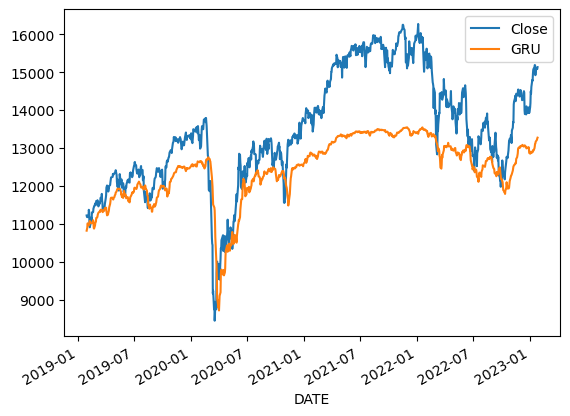

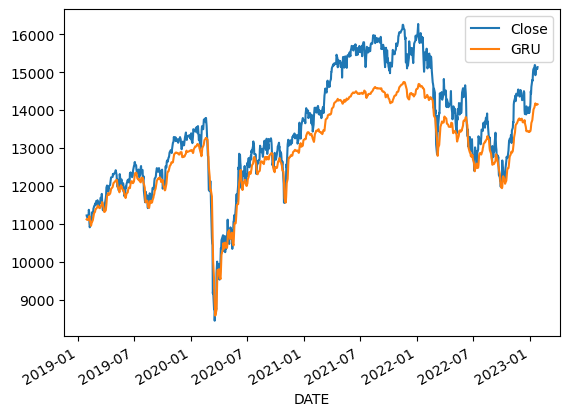

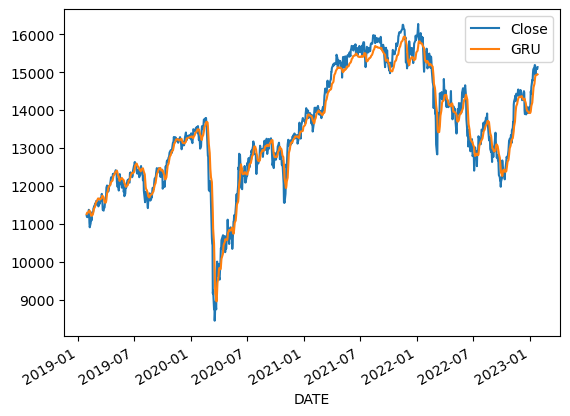

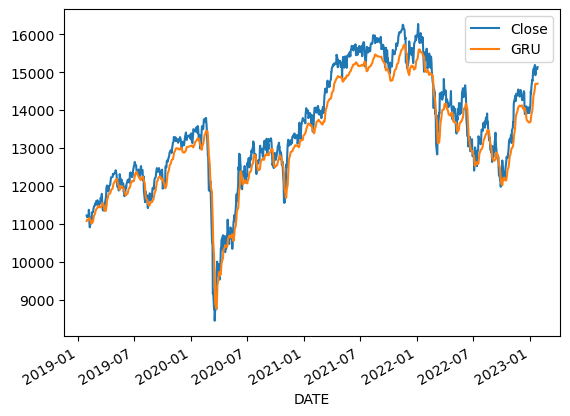

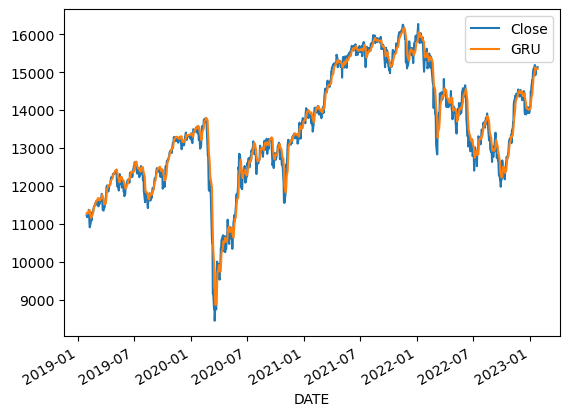

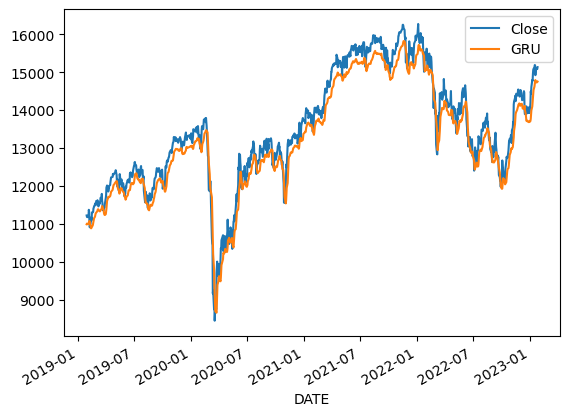

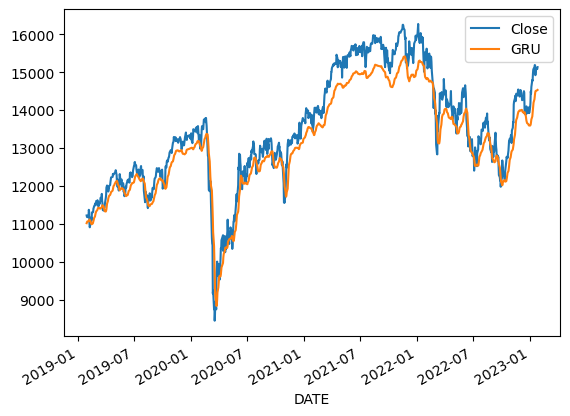

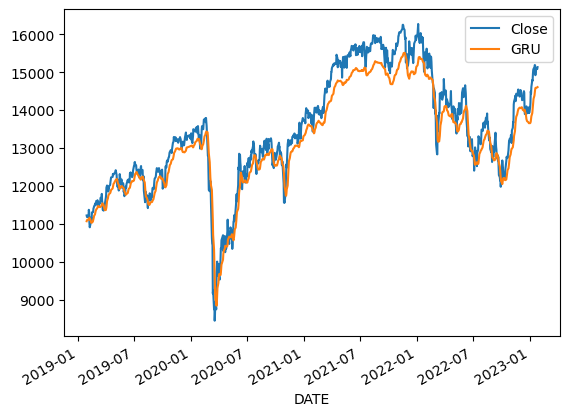

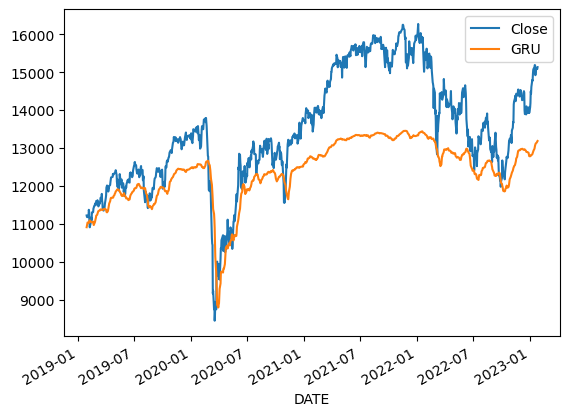

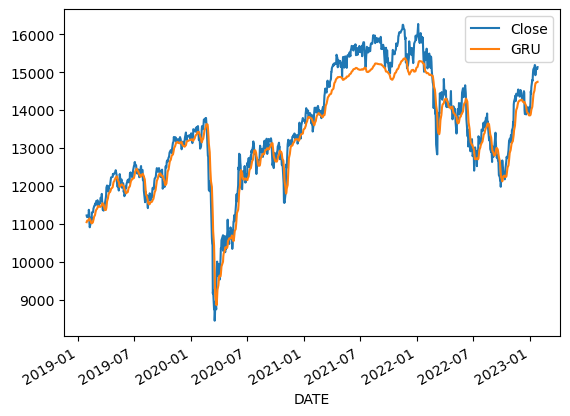

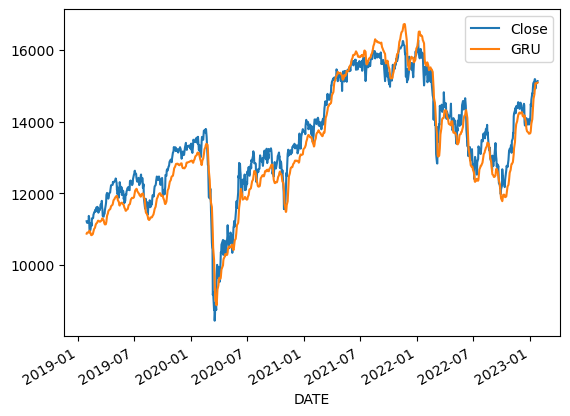

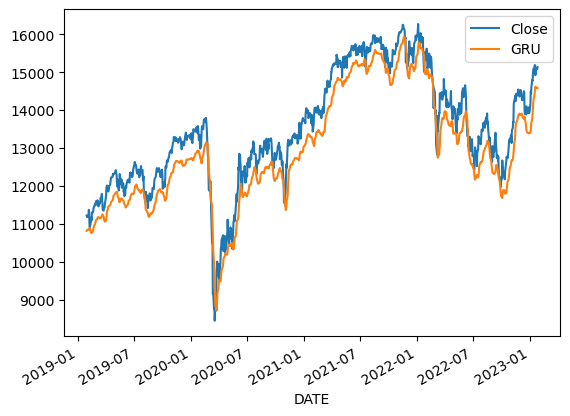

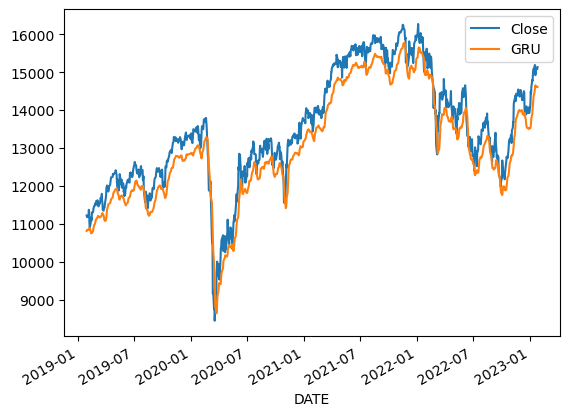

In [53]:
metricForecastDict = {}
metricForecastDictRMSE = {}
metricForecastDictList = []

actFuncList = [sigmoid, tanh, squ_sigmoid, squ_tanh ]

for actFunc in actFuncList:
    print(f"Training with {actFunc} Function")
    futureFrcstNmbr = 90
    df = origDF

    tarColumn = 'Close'
    lookBack = 10

    dfS = df[['Date',tarColumn]]

    resultDF = DLL_Forecast(dfS, lookBack, futureFrcstNmbr, actFunc)
    
    print("===================================================")
    print("\n")

#### MAPE

In [54]:
MAPEModels = [list(metricForecastDict.keys())[i] for i in range(16)]
MAPEVals = [list(metricForecastDict.values())[i][0] for i in range(16)]
MAPEComb = dict(zip(MAPEModels, MAPEVals))
MAPEComb

IndexError: list index out of range

In [ ]:
import plotly.graph_objects as go

# Define the data as a list of dictionaries
data = [{'x': list(MAPEComb.keys()), 'y': list(MAPEComb.values()), 'type': 'bar'},]
# Create the figure
fig = go.Figure(data=data)
# Display the figure
fig.show()

#### RMSE

In [ ]:
RMSEModels = [list(metricForecastDictRMSE.keys())[i] for i in range(16)]
RMSEVals = [list(metricForecastDictRMSE.values())[i][0] for i in range(16)]
RMSEComb = dict(zip(RMSEModels, RMSEVals))
RMSEComb

In [ ]:
import plotly.graph_objects as go

# Define the data as a list of dictionaries
data = [{'x': list(RMSEComb.keys()), 'y': list(RMSEComb.values()), 'type': 'bar'},]
# Create the figure
fig = go.Figure(data=data)
# Display the figure
fig.show()